In [1]:
# !pip install koreanize-matplotlib
import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)  # 열 개수 제한 없음
pd.set_option('display.max_rows', None)  # 행 개수 제한 없음

# 바론과 케니의 매개효과 분석

- Step 1: 독립변수(X) → 종속변수(Y) 영향 확인
- Step 2: 독립변수(X) → 매개변수(M) 영향 확인
- Step 3: 매개변수(M)와 독립변수(X)를 동시에 넣고 종속변수(Y) 예측

	매개효과 존재 조건:
	•	M이 Y에 유의미한 영향을 줘야 함 (b가 유의)  
	•	$c{\prime}$는 c보다 작아야 함. (X의 효과가 줄어야 매개효과가 있다고 볼 수 있어)  
	•	$c{\prime}$가 유의하지 않으면 완전 매개(full mediation).  
	•	$c{\prime}$가 여전히 유의하면 부분 매개(partial mediation).  

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Seed for reproducibility
np.random.seed(42)

# 데이터 생성
n = 200
X = np.random.normal(5, 2, n)          # 운동 시간
M = 0.5 * X + np.random.normal(0, 1, n) # 운동시간이 체력수준에 영향을 줌
Y = 0.6 * M + 0.3 * X + np.random.normal(0, 1, n) # 체력수준과 운동시간 둘 다 건강에 영향

df = pd.DataFrame({'exercise_time': X, 'fitness': M, 'health': Y})

df.head()

,exercise_time,fitness,health
0,5.993428,3.354502,2.216302
1,4.723471,2.922520,2.571179
2,6.295377,4.230740,4.432301
3,8.046060,5.076832,5.506898
4,4.531693,0.888177,1.442349


In [3]:
# X: 운동 시간 (시간/주)
# M: 체력 수준 (점수)
# Y: 건강 상태 (점수)

# X → Y 확인
model1 = ols('health ~ exercise_time', data=df).fit()
print(model1.summary())
#  X → M 확인
model2 = ols('fitness ~ exercise_time', data=df).fit()
print(model2.summary())
# X와 M 동시에 → Y 확인
model3 = ols('health ~ exercise_time + fitness', data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                 health   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.453
Method:                 Least Squares   F-statistic:                     165.5
Date:                Sat, 26 Apr 2025   Prob (F-statistic):           6.35e-28
Time:                        08:02:19   Log-Likelihood:                -309.10
No. Observations:                 200   AIC:                             622.2
Df Residuals:                     198   BIC:                             628.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.1694      0.228      0.742

# Sobel Test (매개효과의 통계적 유의성 검정)

In [4]:
from math import sqrt
from scipy.stats import norm

# a = X -> M의 계수
# sa = X -> M의 표준오차
a = model2.params['exercise_time']
sa = model2.bse['exercise_time']

# b = M -> Y의 계수 (X 통제 후)
# sb = M -> Y의 표준오차
b = model3.params['fitness']
sb = model3.bse['fitness']

# Sobel test statistic
sobel_num = a * b
sobel_den = sqrt(b**2 * sa**2 + a**2 * sb**2)
sobel_z = sobel_num / sobel_den
p_value = 2 * (1 - norm.cdf(abs(sobel_z)))

print(f"Sobel Test Z-value: {sobel_z:.4f}")
print(f"Sobel Test p-value: {p_value:.4f}")
# p-value < 0.05이면 매개효과가 통계적으로 유의함.

Sobel Test Z-value: 7.1045
Sobel Test p-value: 0.0000


# Bootstrapping을 이용해서 매개효과의 95% 신뢰구간을 추정하는 방법

In [5]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 부트스트랩 함수
def bootstrap_mediation(df, n_bootstrap=5000):
    boot_mediation_effects = []

    for _ in range(n_bootstrap):
        # 1. 복원추출 (with replacement)
        sample = df.sample(n=len(df), replace=True)

        # 2. X -> M
        model_a = ols('fitness ~ exercise_time', data=sample).fit()
        a = model_a.params['exercise_time']

        # 3. X, M -> Y
        model_b = ols('health ~ exercise_time + fitness', data=sample).fit()
        b = model_b.params['fitness']

        # 4. 매개효과 a*b 저장
        mediation_effect = a * b
        boot_mediation_effects.append(mediation_effect)

    return np.array(boot_mediation_effects)

# 실제 부트스트랩 수행
boot_effects = bootstrap_mediation(df)

# 신뢰구간 계산 (percentile method)
lower = np.percentile(boot_effects, 2.5)
upper = np.percentile(boot_effects, 97.5)
mean_effect = np.mean(boot_effects)

print(f"Bootstrapped 평균 매개효과: {mean_effect:.4f}")
print(f"Bootstrapped 95% 신뢰구간: ({lower:.4f}, {upper:.4f})")

Bootstrapped 평균 매개효과: 0.3194
Bootstrapped 95% 신뢰구간: (0.2245, 0.4211)


# 지수예측모델 (Exponential Smoothing Model) 이란?

In [6]:
# 시계열 분석에서 미래를 예측하기 위해 사용되는 대표적인 방법 중 하나야.
# 과거 데이터에 지수적으로 가중치를 두고 평균을 내서 예측값을 만든다고 해서 지수평활법 (exponential smoothing) 이라고 불려.
# 특히 단기 예측에서 성능이 뛰어난 걸로 잘 알려져 있어.

# !pip install statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 예제 데이터: 항공 승객 수
from statsmodels.datasets import get_rdataset
airpassengers = get_rdataset("AirPassengers", package="datasets").data
airpassengers['time'] = pd.date_range(start='1949-01', periods=len(airpassengers), freq='M')
airpassengers = airpassengers.set_index('time')
ts = airpassengers['value']

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


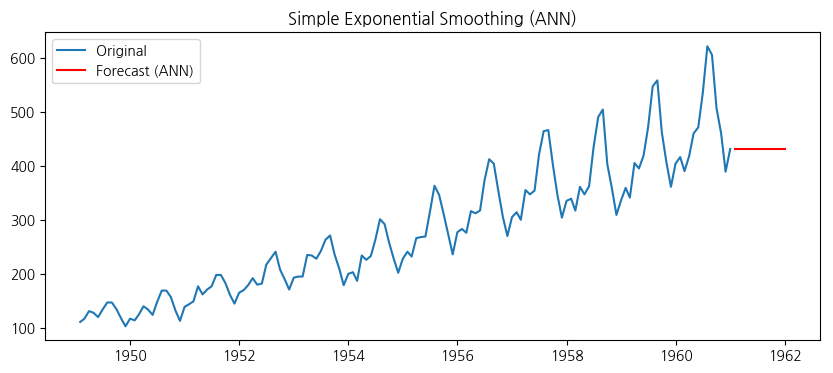

In [7]:
# 단순지수평활법 (Simple Exponential Smoothing / ANN)
# 수준(평균)만 고려, 추세와 계절성 없음
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

model_ann = SimpleExpSmoothing(ts).fit()
forecast_ann = model_ann.forecast(12)

# 시각화
plt.figure(figsize=(10,4))
plt.plot(ts, label='Original')
plt.plot(forecast_ann, label='Forecast (ANN)', color='red')
plt.title('Simple Exponential Smoothing (ANN)')
plt.legend()
plt.show()

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


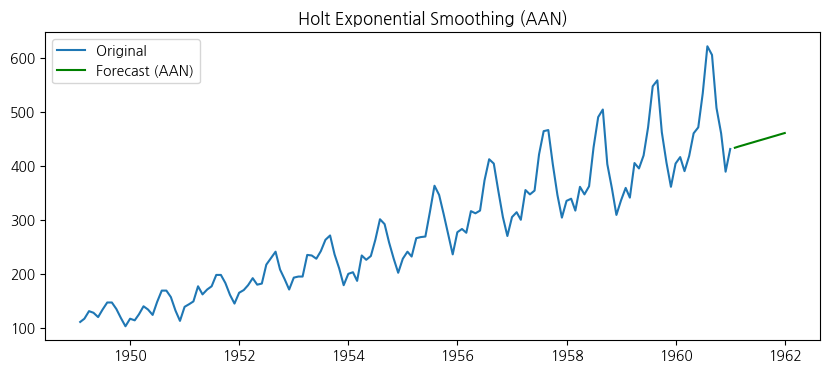

In [8]:
# Holt’s 지수평활법 (수준 + 추세 / AAN)

from statsmodels.tsa.holtwinters import Holt

model_aan = Holt(ts).fit()
forecast_aan = model_aan.forecast(12)

plt.figure(figsize=(10,4))
plt.plot(ts, label='Original')
plt.plot(forecast_aan, label='Forecast (AAN)', color='green')
plt.title('Holt Exponential Smoothing (AAN)')
plt.legend()
plt.show()

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


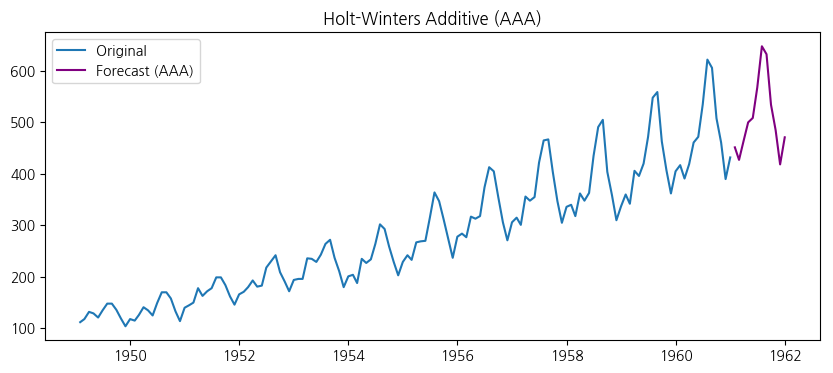

In [9]:
# Holt-Winters 지수평활법 (수준 + 추세 + 계절성 / AAA, AAM, MAM 등)

model_aaa = ExponentialSmoothing(ts,
                                  trend='add',
                                  seasonal='add',
                                  seasonal_periods=12).fit()
forecast_aaa = model_aaa.forecast(12)

plt.figure(figsize=(10,4))
plt.plot(ts, label='Original')
plt.plot(forecast_aaa, label='Forecast (AAA)', color='purple')
plt.title('Holt-Winters Additive (AAA)')
plt.legend()
plt.show()

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


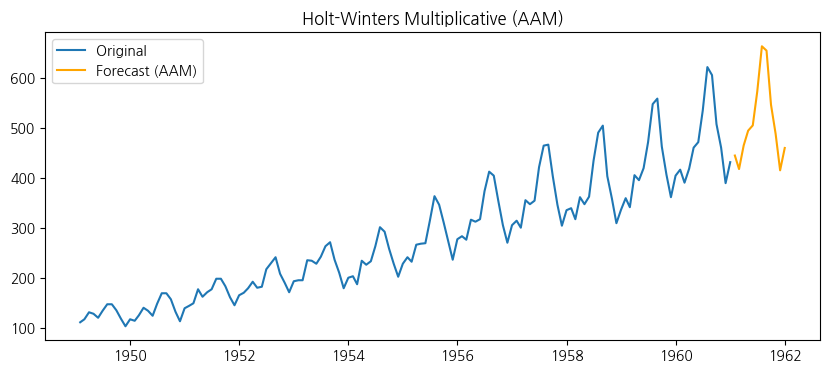

In [10]:
# Multiplicative 계절성 포함 (AAM)

model_aam = ExponentialSmoothing(ts,
                                  trend='add',
                                  seasonal='mul',
                                  seasonal_periods=12).fit()
forecast_aam = model_aam.forecast(12)

plt.figure(figsize=(10,4))
plt.plot(ts, label='Original')
plt.plot(forecast_aam, label='Forecast (AAM)', color='orange')
plt.title('Holt-Winters Multiplicative (AAM)')
plt.legend()
plt.show()

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/holtwinters/model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


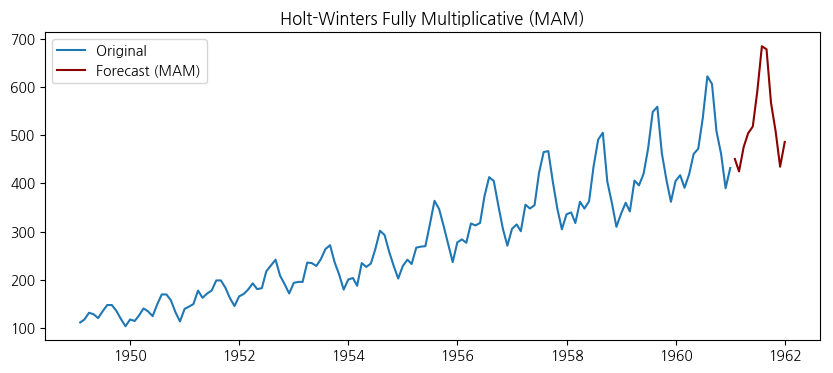

In [11]:
# 완전 곱셈형 (MAM)

model_mam = ExponentialSmoothing(ts,
                                  trend='mul',
                                  seasonal='mul',
                                  seasonal_periods=12).fit()
forecast_mam = model_mam.forecast(12)

plt.figure(figsize=(10,4))
plt.plot(ts, label='Original')
plt.plot(forecast_mam, label='Forecast (MAM)', color='darkred')
plt.title('Holt-Winters Fully Multiplicative (MAM)')
plt.legend()
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 평가 구간 설정 (예측 구간과 동일하게 마지막 12개월을 평가)
train = ts[:-12]
test = ts[-12:]

# 모델별 예측
ann = SimpleExpSmoothing(train).fit().forecast(12)
aan = Holt(train).fit().forecast(12)
aaa = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit().forecast(12)
aam = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12).fit().forecast(12)
mam = ExponentialSmoothing(train, trend='mul', seasonal='mul', seasonal_periods=12).fit().forecast(12)

# 오차 계산 함수
def calculate_errors(true, pred):
    mae = mean_absolute_error(true, pred)
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(true, pred)
    return [mae, mse, rmse, mape]

# 모든 결과 저장
results = {
    'ANN': calculate_errors(test, ann),
    'AAN': calculate_errors(test, aan),
    'AAA': calculate_errors(test, aaa),
    'AAM': calculate_errors(test, aam),
    'MAM': calculate_errors(test, mam)
}

# 결과 출력
error_df = pd.DataFrame(results, index=['MAE', 'MSE', 'RMSE', 'MAPE (%)']).T
import seaborn as sns
import matplotlib.pyplot as plt

print(error_df.round(2))

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency inform

       MAE       MSE    RMSE  MAPE (%)
ANN  76.14  10634.65  103.12     14.28
AAN  68.08   8913.36   94.41     12.75
AAA  13.38    288.31   16.98      2.80
AAM  10.30    249.96   15.81      2.21
MAM  20.85    666.14   25.81      4.33


# 요인분석, 타당도 분석, 집중타당도(convergent validity), 판별타당도(discriminant validity), 측정타당도

In [ ]:
! pip install factor_analyzer pingouin pandas numpy

import pandas as pd
from sklearn.datasets import fetch_openml
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo
import numpy as np

# 1. 예제 데이터 로딩: Big Five 유사 성격 데이터셋
df = fetch_openml("BigFive", version=1, as_frame=True).frame

# 결측치 제거 및 일부 문항 선택 (A1~A5, C1~C5, E1~E5, N1~N5, O1~O5)
df = df.dropna()
columns = [col for col in df.columns if col[:2] in \
           ['A1','A2','A3','A4','A5','C1','C2','C3','C4','C5','E1','E2','E3','E4','E5']]
df = df[columns].astype(float)

# 2. KMO와 Bartlett의 구형성 검정
chi_square_value, p_value = calculate_bartlett_sphericity(df)
kmo_all, kmo_model = calculate_kmo(df)

print(f"Bartlett Test p-value: {p_value:.4f}")
print(f"KMO Measure: {kmo_model:.4f}")

# 3. 탐색적 요인분석 (EFA)
fa = FactorAnalyzer(n_factors=5, rotation="varimax")
fa.fit(df)

# 요인적재량 확인
loadings = pd.DataFrame(fa.loadings_, index=df.columns)
print("\n[Factor Loadings]")
print(loadings.round(3))

# 4. 집중타당도: AVE 계산 함수
def calculate_ave(loadings):
    ave_scores = []
    for i in range(loadings.shape[1]):
        squared_loadings = loadings.iloc[:, i] ** 2
        ave = squared_loadings.mean()
        ave_scores.append(ave)
    return ave_scores

ave_list = calculate_ave(loadings)
print("\n[AVE per Factor]")
for i, ave in enumerate(ave_list, 1):
    print(f"Factor {i}: AVE = {ave:.3f} {'✓' if ave >= 0.5 else '✗'}")

1) Bartlett의 구형성 검정
	•	p < 0.05 → 요인분석 적합

2) KMO 검정
	•	0.6 이상이면 요인분석 적절

3) 요인적재량
	•	특정 문항이 어느 요인에 강하게 적재되었는지 확인
	•	0.5 이상이면 집중타당도 확보 가능

4) AVE
	•	각 요인의 평균 분산 추출 값
	•	0.5 이상이면 집중타당도 확보


In [ ]:
# 문항별 요인 배정
factor_membership = loadings.abs().idxmax(axis=1)

# 각 요인별 문항들 그룹핑
factor_items = {f'Factor{i+1}': loadings.index[factor_membership == f] for i, f in enumerate(loadings.columns)}

# 요인별 하위 문항 평균값으로 요인 점수 계산
factor_scores = pd.DataFrame()
for factor, items in factor_items.items():
    factor_scores[factor] = df[items].mean(axis=1)

# 상관행렬
cor_matrix = factor_scores.corr()
ave_sqrt = np.sqrt(ave_list)

# AVE 제곱근 vs 상관계수 비교
print("\n[Discriminant Validity: AVE^0.5 vs Correlation]")
for i in range(len(ave_sqrt)):
    for j in range(len(ave_sqrt)):
        if i != j:
            print(f"{factor_scores.columns[i]} vs \
            {factor_scores.columns[j]}: corr = {cor_matrix.iloc[i,j]:.3f}, sqrt(AVE_i) = {ave_sqrt[i]:.3f}, sqrt(AVE_j) = {ave_sqrt[j]:.3f}")

#  조절효과란?

In [ ]:
# X와 Y의 관계를 ‘조절’하는 역할을 하는 변수야.
# 조절효과 분석 = 상호작용효과 (Interaction Effect)

df['XZ'] = df['X'] * df['Z']

import statsmodels.formula.api as smf

model = smf.ols('Y ~ X + Z + XZ', data=df).fit()
print(model.summary())

# XZ의 p-value < 0.05 → 조절효과(상호작용효과)가 있음
# 회귀계수가 양수/음수인지에 따라 강화 / 약화 / 방향전환 판단 가능

# XZ의 회귀계수(p-value < 0.05) → 조절효과 있음
# 회귀계수(+)면: Z가 클수록 X와 Y의 관계가 강해짐
# 회귀계수(-)면: Z가 클수록 X와 Y의 관계가 약해짐 또는 반전